- Esse notebook conterá a aplicação do algoritmo t-SNE. Ele é não-linear, diferentemente do PCA, e foca em preservar distâncias locais. Se dois times jogaram de forma quase idêntica, o t-SNE faz uma força gravitacional para colar os dois na mesma "ilha" do gráfico, mesmo que para isso ele precise distorcer a visão global.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

# carregamento e padronização

df_season = pd.read_parquet("dados_reducao.parquet")

features = ['PF', 'PA', 'Off_Pass_Yds', 'Off_Rush_Yds', 'Off_Carries', 
            'Off_Turnovers', 'Def_Sacks_Produced', 'Def_Turnovers_Forced']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_season[features])


# aplicação do t-SNE

# Perplexity é o hiperparâmetro "mágico", o qual eu ainda não havia entrado em contato, e, geralmente, tem valor entre 5 e 50.
# ele define quantos "vizinhos" o algoritmo deve considerar ao agrupar os times.
tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)

df_season['TSNE1'] = X_tsne[:, 0]
df_season['TSNE2'] = X_tsne[:, 1]

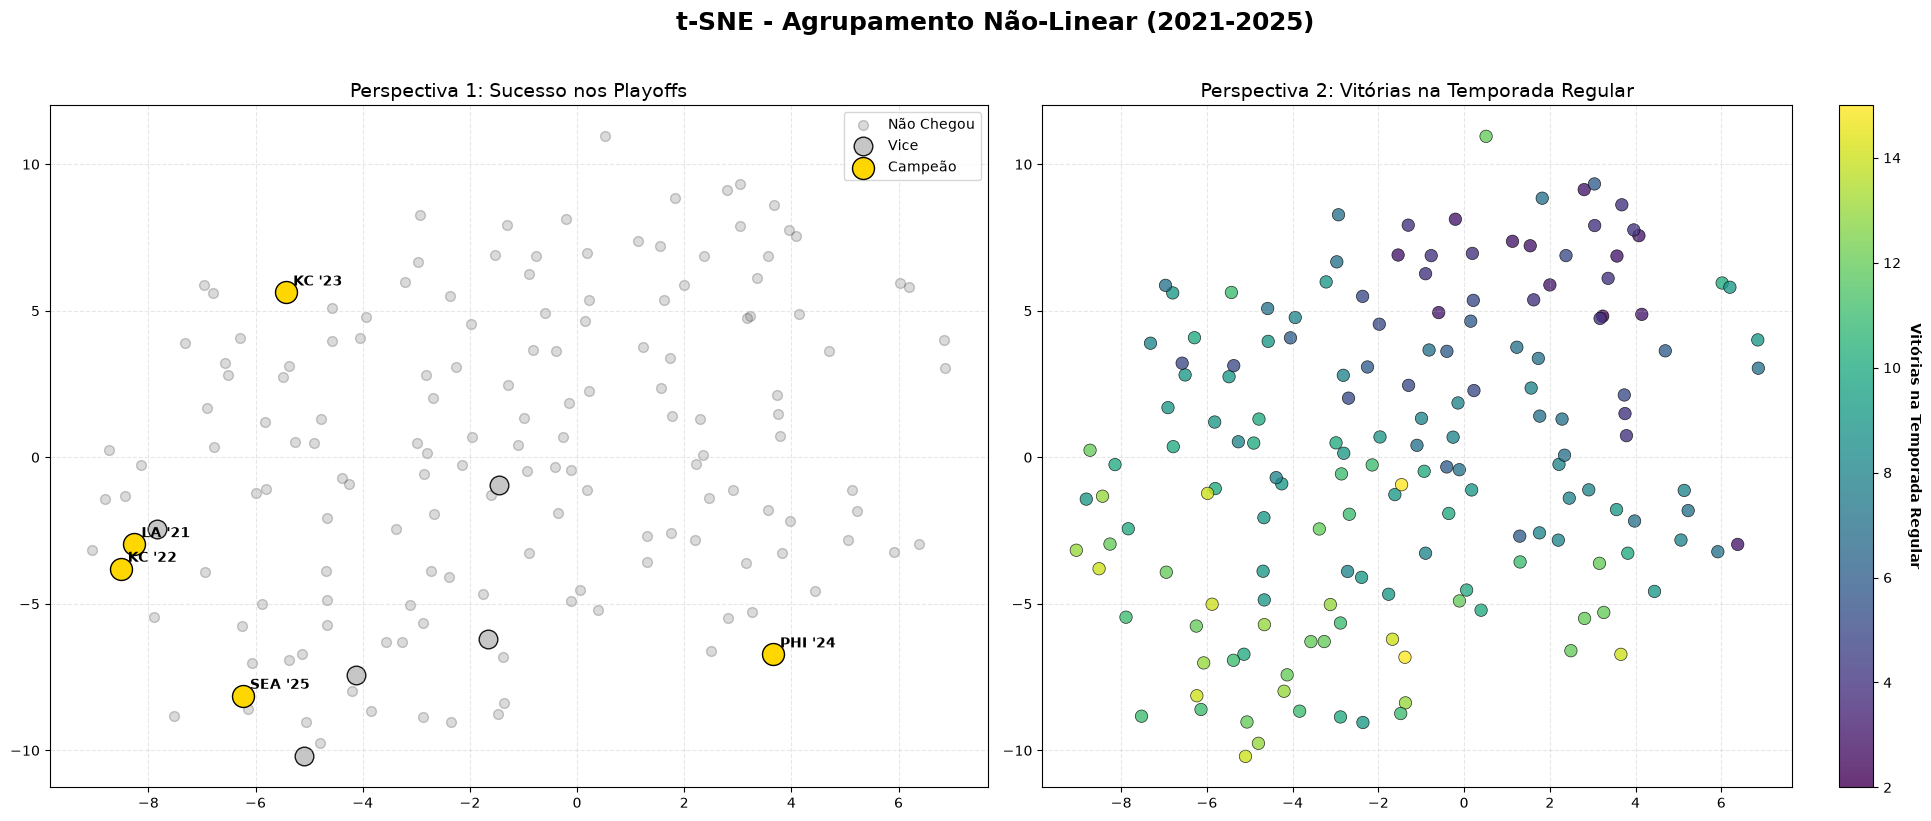

In [2]:
# visualização em perspectiva dupla, assim como o PCA

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
plt.suptitle('t-SNE - Agrupamento Não-Linear (2021-2025)', fontsize=18, fontweight='bold', y=1.02)

# --- Gráfico 1: Status Super Bowl ---
cores = {'Campeão': '#FFD700', 'Vice': '#C0C0C0', 'Não Chegou': '#4a4a4a', '-': '#4a4a4a'}
tamanhos = {'Campeão': 250, 'Vice': 180, 'Não Chegou': 50, '-': 50}
alphas = {'Campeão': 1.0, 'Vice': 0.9, 'Não Chegou': 0.2, '-': 0.2}

for status in ['-', 'Não Chegou', 'Vice', 'Campeão']:
    subset = df_season[df_season['Status_SB'] == status]
    if not subset.empty:
        ax1.scatter(subset['TSNE1'], subset['TSNE2'], c=cores[status], s=tamanhos[status], 
                    alpha=alphas[status], label=status, edgecolors='black', linewidth=1)

campeoes = df_season[df_season['Status_SB'] == 'Campeão']
for idx, row in campeoes.iterrows():
    ax1.annotate(f"{row['team']} '{str(row['season'])[-2:]}", (row['TSNE1'], row['TSNE2']),
                 xytext=(5, 5), textcoords='offset points', fontsize=10, fontweight='bold')

ax1.set_title('Perspectiva 1: Sucesso nos Playoffs', fontsize=14)
ax1.legend(loc='best')
ax1.grid(True, linestyle='--', alpha=0.3)

# --- Gráfico 2: Vitórias na Temporada ---
scatter_wins = ax2.scatter(df_season['TSNE1'], df_season['TSNE2'], 
                           c=df_season['Reg_Season_Wins'], cmap='viridis', 
                           s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

cbar = plt.colorbar(scatter_wins, ax=ax2)
cbar.set_label('Vitórias na Temporada Regular', rotation=270, labelpad=15, fontweight='bold')

ax2.set_title('Perspectiva 2: Vitórias na Temporada Regular', fontsize=14)
ax2.grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

- Observando o gráfico da perspectiva 1, dá pra perceber que os campeões estão bem mais focados pro canto inferior esquerdo, destacando-se os times LA '21 e KC '22, que estão praticamente colados um no outro. O t-SNE conseguiu identificar que o Los Angeles Rams de 2021 e o Kansas City Chiefs de 2022 jogaram um futebol americano estatisticamente muito parecido.

- O Philadelphia Eagles de 2024, que está recorrentemente aparecendo como um outlier muito fora dos padrões, está isolado no quadrante inferior direito, muito distante dos outros campeões. Isso corrobora o que vimos no Isolation Forest. Eles não venceram seguindo a cartilha dos outros campeões; eles venceram sendo a maior anomalia da década.

- Sob a perspectiva 2, observa-se uma concentração de pontos amarelos e verde-claros (times com 11 a 15 vitórias) aglomerados na parte inferior esquerda. O t-SNE entendeu e conseguiu distinguir razoavelmente a combinação específica de estatísticas que leva á vitória na NFL. Os times que dominam a liga jogam de forma parecida entre si, e o algoritmo os puxou para o mesmo espaço/região. É nessa região que vimos a concentração de Campeões e Vices na perspectiva 1.

- Pra direção superior direita, temos um foco de pontos roxos escuros (times com 2 a 5 vitórias). O algoritmo identificou moderadamente que o fracasso na NFL tem uma assinatura estatística, assim como fez pros vencedores. Esses times não estão espalhados aleatoriamente; eles cometem os mesmos erros (muitos turnovers, poucos sacks, baixo controle de relógio) e, por isso, foram confinados à mesma região de mediocridade no gráfico.

- Separando a elite do fracasso, há uma região intermédiária, com pontos de todas as cores. Estes são os times que tentam imitar a fórmula da elite, mas falham em um ou dois aspectos cruciais, sendo então times medianos com uma quantidada moderada de vitórias, ou então times que conseguiram ganhar mais do que deveriam, independente de suas estatísticas medianas, ou o lado contrário, times que perderam mais do que "deveriam". É aqui que entam aspectos como 'Clutch', podem haver times que, se estiverem próximos no placar ao final do jogo, eles dão um jeito de ganhar, e o oposto também se aplicando, na presença dos 'pipoqueiros'.

- Uma parte curiosa desse gráfico são os poucos pontos amarelo, e verdes, no canto inferior direito, como já foi estabelecido, aquele ponto amarelo é o Eagles de 24, então esses outros times verdes ao redor, devem ser times que jogaram um estilo semelhante ao do Eagles de 24, e também conseguiram razoável sucesso assim, mesmo que o jeito que eles jogaram estatisticamente não se pareça muito com o resto da elite. Isso casa com a Isolation Forest, que marcou times como Philadelphia Eagles de 2024 e o Detroit Lions de 2024. Eles venceram muito, mas através de táticas extremas  que os isolaram topologicamente.

- Ao contrário do que foi mostrado no PCA, aqui dá pra ver que o KC de 23 também está isolado de certa forma, tanto que ao redor dele, na perspectiva 2, todos os times são azul ou verde-escuro, times fracos, indicando que algo fora das estatísticas trouxe a vitória pra eles. Tal algo sendo o Patrick Mahomes e sua decisividade nos playoffs.

- O t-SNE precisa de milhares de pontos para gerar gravidade suficiente e rasgar uma nuvem em ilhas separadas. Como temos apenas 160 pontos (32 times x 5 anos), ele não teve "massa" suficiente para concluir uma separação topológica adequada. É por isso que o UMAP se tornou o estado da arte e desbancou o t-SNE. O UMAP lida muito bem com datasets pequenos e tenta preservar a "vizinhança global" (o que o PCA faz), junto com a "vizinhança local" (o que o t-SNE tenta fazer).